## ARCH Volatility Forecasting Model

In this notebook, we build and evaluate a ARCH (Autoregressive Conditional Heteroskedasticity) model to forecast the future realized volatility of 2800.HK.  

Imports

In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

### Load Processed Volatility & Return Data

We import the pre-exported datasets created in the data-processing notebook

In [2]:
# Load log returns for naive baseline volatility computation
log_ret = pd.read_excel('../data/hsi_log_ret.xlsx').set_index('date')

log_ret # Quick display for sanity check

,2800.HK
date,
2002-05-14,-0.004246
2002-05-15,0.012685
2002-05-16,0.000000
2002-05-17,0.012526
2002-05-21,-0.025211
...,...
2025-12-03,-0.011499
2025-12-04,0.007681
2025-12-05,0.005341


### Fit ARCH(7) and Generate Out-of-Sample Volatility Forecasts

We estimate a ARCH(7) model on the training period of daily log returns. 

In [3]:
# Define out-of-sample cutoff date
split_date = '2021-12-31'

# Scale returns to percentages (ARCH/GARCH models typically assume % returns)
model = arch_model(log_ret * 100, vol='ARCH', p=7,)

# Fit ARCH model using only data before the split_date (prevents look-ahead bias)
res = model.fit(disp='off', last_obs=split_date)

# Forecast future variance over the next 21 trading days (≈ 1 month)
# Monte-Carlo forecasting (1000 simulated paths)
forecasts = res.forecast(
    horizon=21, 
    start=split_date,
).variance

# Aggregate 21-day variance to match realized volatility target’s definition
sigma2_5_forecast = forecasts.sum(axis=1)

# Convert variance forecast into log-realized volatility units for evaluation
y_pred = 0.5 * np.log(sigma2_5_forecast / (100 * 100))

res, y_pred # Display fitted model summary and volatility forecasts


(                      Constant Mean - ARCH Model Results                      
 Dep. Variable:                2800.HK   R-squared:                       0.000
 Mean Model:             Constant Mean   Adj. R-squared:                  0.000
 Vol Model:                       ARCH   Log-Likelihood:               -7972.06
 Distribution:                  Normal   AIC:                           15962.1
 Method:            Maximum Likelihood   BIC:                           16020.5
                                         No. Observations:                 4846
 Date:                Fri, Dec 12 2025   Df Residuals:                     4845
 Time:                        17:59:10   Df Model:                            1
                                  Mean Model                                 
                  coef    std err          t      P>|t|      95.0% Conf. Int.
 ----------------------------------------------------------------------------
 mu             0.0417  1.699e-02      2.452  

### Align True vs. Predicted Volatility Series

In [4]:
# Extract true realized volatility strictly from the OOS period
y_true = log_ret['2021-12-31':]['2800.HK']
y_true = (y_true**2).rolling(21).sum().shift(-21)
y_true = 0.5 * np.log(y_true + 1e-12)
y_true = y_true.dropna()

# Align predictions and true values on matching dates only
valid_idx = y_true.index.intersection(y_pred.index)

y_true = y_true.loc[valid_idx]
y_pred = y_pred.loc[valid_idx]

### Forecast Performance Evaluation

We assess how well the ARCH model predicts future realized volatility

In [6]:
def qlike(y_true, y_pred):
    """
    QLIKE loss for volatility forecasts.
    Inputs must be in LEVELS, not logs.
    """
    eps = 1e-12
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(y_true / (y_pred + eps) - np.log(y_true / (y_pred + eps)) - 1)
true_vol = np.exp(y_true)   # if true_vals = log(rv)
pred_vol = np.exp(y_pred)       # if preds = predicted mean in log(rv)
qlike_value = qlike(true_vol, pred_vol)

In [7]:
# Performance evaluation of baseline model
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f'MSE: {mse:.3f}, MAE: {mae:.3f}, QLIKE: {qlike_value:.3f}')

MSE: 0.097, MAE: 0.222, QLIKE: 0.057


### Convert Volatility Back to Annualized Percentage Units

The arch and true volatility series are currently expressed as log-realized variance.
To make the evaluation interpretable, we convert them to annualized volatility percentages.

In [8]:
ann_true = np.exp(y_true) * np.sqrt(12) *100
ann_pred = np.exp(y_pred) * np.sqrt(12) *100

### Visualizing ARCH vs. True Annualized Volatility

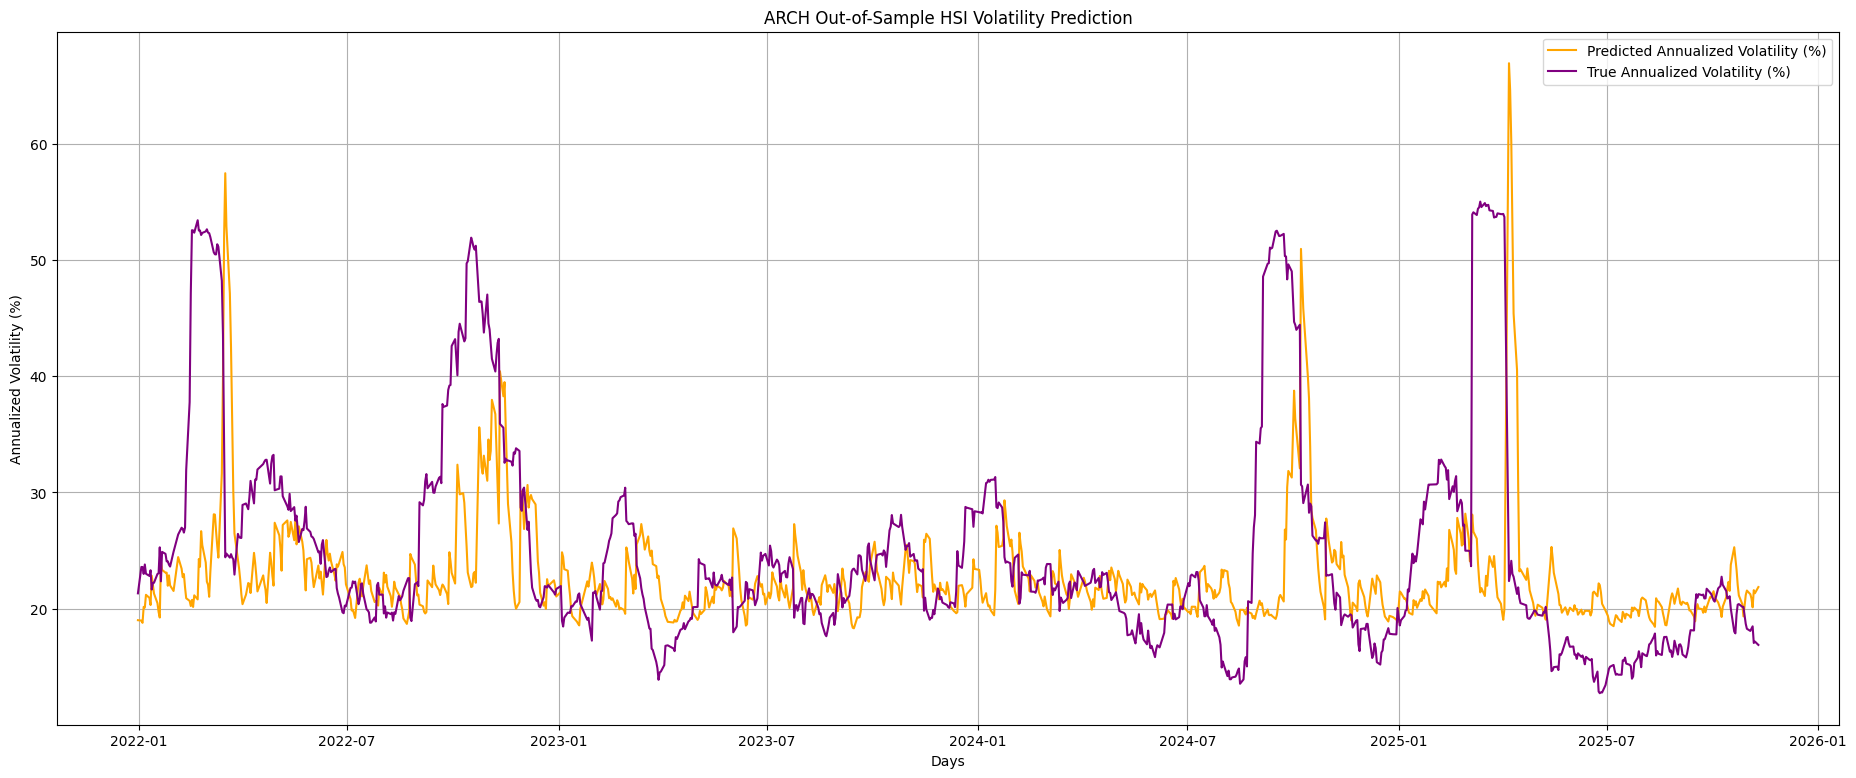

In [9]:
plt.figure(figsize=(23,9))
plt.plot(ann_pred, label='Predicted Annualized Volatility (%)', c='orange') # CUHK Colors
plt.plot(ann_true, label='True Annualized Volatility (%)', c='purple') # CUHK Colors
plt.title('ARCH Out-of-Sample HSI Volatility Prediction')
plt.xlabel('Days')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid()

### Export GARCH OOS Forecasts

In [12]:
# y_pred.to_excel('../results/arch_oos_pred.xlsx')